### Cómo usar esta práctica

Esta práctica recorre **los mismos ocho puntos de decisión que evalúa el examen**, en el mismo orden.
Lo que cambiará en el examen es el conjunto de datos: **las propiedades serán distintas y, por lo tanto,
varias decisiones correctas serán otras**.


Los dos **retos finales** son deliberadamente distintos al resto: te muestran casos en los que la respuesta
del día **no aplica**. Ese formato sí aparecerá en el examen.

---

### Contexto clínico

Registro de una **cohorte de insuficiencia cardiaca crónica**. Cada fila es un paciente.
Objetivo: predecir `reingreso_30d`.

| Variable | Tipo | Descripción |
|---|---|---|
| `id_paciente` | Texto | Identificador |
| `edad` | Numérica | Años cumplidos |
| `sexo` | Categórica nominal | M / F |
| `frec_cardiaca` | Numérica | Frecuencia cardiaca (lpm) |
| `presion_sistolica` | Numérica | Presión arterial sistólica (mmHg) |
| `bnp` | Numérica | Péptido natriurético tipo B (pg/mL) |
| `creatinina` | Numérica | Creatinina sérica (mg/dL) |
| `colesterol_total` | Numérica | Colesterol total (mg/dL) |
| `fevi_ingreso` | Numérica | Fracción de eyección (%) — *reservada para el reto final* |
| `tipo_dolor` | Categórica nominal | TA / AA / DNA / ASINT |
| `pendiente_st` | Categórica nominal | Ascendente / Plana / Descendente |
| `reingreso_30d` | Binaria | **Variable objetivo** |


In [1]:
# ============================================================
#  CELDA DADA — ejecútala sin modificarla
# ============================================================
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, recall_score)

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (11, 3.2), "axes.grid": True,
                     "grid.alpha": .3, "font.size": 9})

SEMILLA = 42


def lambda_ic(x, alpha=0.05):
    """Lambda de Yeo-Johnson por maxima verosimilitud + IC 95 % (verosimilitud perfilada).

    Devuelve (lambda, limite_inferior, limite_superior).
    Si el IC contiene 1.0, la transformacion NO es estadisticamente necesaria.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    lam = stats.yeojohnson_normmax(x)
    corte = stats.yeojohnson_llf(lam, x) - 0.5 * stats.chi2.ppf(1 - alpha, 1)
    malla = np.linspace(lam - 6, lam + 6, 2001)
    llf = np.array([stats.yeojohnson_llf(l, x) for l in malla])
    dentro = malla[llf >= corte]
    return lam, dentro.min(), dentro.max()


def perfil(df, columnas):
    """Tabla diagnostica: sesgo, minimo, negativos, ceros, lambda e IC 95 %."""
    filas = []
    for c in columnas:
        s = df[c].dropna().astype(float)
        lam, lo, hi = lambda_ic(s)
        filas.append({
            "variable": c,
            "sesgo": round(float(stats.skew(s)), 2),
            "min": round(float(s.min()), 2),
            "negativos": int((s < 0).sum()),
            "ceros": int((s == 0).sum()),
            "lambda": round(lam, 3),
            "IC_inf": round(lo, 2),
            "IC_sup": round(hi, 2),
            "IC_contiene_1": bool(lo <= 1 <= hi),
        })
    return pd.DataFrame(filas)


def cargar(nombre):
    """Busca el CSV junto al notebook o en ./datos/."""
    for r in (nombre, os.path.join("datos", nombre),
              os.path.join("..", "datos", nombre)):
        if os.path.exists(r):
            return pd.read_csv(r)
    raise FileNotFoundError(
        f"No encuentro '{nombre}'. Colocalo en la misma carpeta que este notebook.")


print("Entorno listo.")

Entorno listo.


---
## Punto 0 — Ingestión e inspección inicial
*Subtema 3.2*

In [ ]:
df = cargar("cohorte_ic_repaso.csv")

print("Dimensiones:", df.shape)
print()
print(df.dtypes.to_string())
print()
print("Distribución del desenlace:")
print(df["reingreso_30d"].value_counts(normalize=True).round(3).to_string())
df.head()


# Cargar el archivo
#df = cargar("cohorte_ic_repaso.csv")

# Ver número de filas y columnas
#print("Dimensiones:", df.shape)

# Ver el tipo de dato de cada columna
#print(df.dtypes.to_string())

# Ver la proporción de cada clase de la variable objetivo
#print(df["reingreso_30d"].value_counts(normalize=True).round(3).to_string())

# Mostrar las primeras 5 filas
#df.head()


### ¿Qué hace cada comando?

# `df.shape` → muestra **filas y columnas**.
# `df.dtypes` → muestra el **tipo de dato** de cada variable.
# `df["columna"]` → selecciona una columna específica.
# `value_counts()` → cuenta cuántas veces aparece cada valor.
# `value_counts(normalize=True)` → muestra la **proporción** de cada valor.
# `.round(3)` → redondea a 3 decimales.
# `.to_string()` → muestra el resultado completo como texto.
# `df.head()` → muestra las **primeras 5 filas**.

### Idea clave para el examen

#Este bloque sirve para hacer una **exploración inicial del dataset**: revisar su tamaño, tipos de datos, distribución de la variable objetivo y observar las primeras filas.


Dimensiones: (900, 12)

id_paciente              str
edad                 float64
sexo                     str
frec_cardiaca        float64
presion_sistolica    float64
bnp                  float64
creatinina           float64
colesterol_total     float64
fevi_ingreso         float64
tipo_dolor               str
pendiente_st             str
reingreso_30d          int64

Distribución del desenlace:
reingreso_30d
1    0.508
0    0.492


,id_paciente,edad,sexo,frec_cardiaca,presion_sistolica,bnp,creatinina,colesterol_total,fevi_ingreso,tipo_dolor,pendiente_st,reingreso_30d
0,IC-00001,37.0,M,75.0,124.0,545.8,0.60,NaN,62.0,ASINT,Descendente,0
1,IC-00002,64.0,F,80.0,116.0,370.0,0.93,146.0,43.0,AA,Ascendente,0
2,IC-00003,76.0,M,83.0,139.0,91.1,1.33,NaN,57.0,AA,Ascendente,0
3,IC-00004,82.0,M,88.0,109.0,474.2,1.35,263.0,38.0,DNA,Ascendente,1
4,IC-00005,72.0,F,78.0,155.0,154.3,0.63,134.0,50.0,TA,Ascendente,0


**Anota tres observaciones** de esta primera inspección que puedan condicionar decisiones posteriores.

> 1. Nueve variables numéricas y tres de texto: las tres de texto tendrán que codificarse antes de modelar.
> 2. El desenlace está **razonablemente balanceado** (≈ 50 % de reingresos). Esto tendrá consecuencias en el
>    Punto 8: aquí la accuracy sí es una métrica informativa.
> 3. `colesterol_total` es la única con valores faltantes visibles, y su mínimo es sospechosamente bajo.


---
## Punto 1 — Integridad y segregación de datos
*Subtemas 3.2 y 3.4*

In [ ]:
# Antes de partir, siempre se verifica la unidad de observación
print("Filas:            ", len(df))
print("Pacientes únicos: ", df["id_paciente"].nunique())
print("Duplicados:       ", len(df) - df["id_paciente"].nunique())

# Verificar la unidad de observación antes de partir los datos

# Número total de filas
#print("Filas:            ", len(df))

# Número de pacientes diferentes
#print("Pacientes únicos: ", df["id_paciente"].nunique())

# Número de pacientes duplicados
#print("Duplicados:       ", len(df) - df["id_paciente"].nunique())


### ¿Qué hace cada comando?

# `len(df)` → cuenta el **número total de filas** del dataset.
# `df["id_paciente"]` → selecciona la columna que identifica a cada paciente.
# `.nunique()` → cuenta cuántos **valores diferentes/únicos** hay.
# `len(df) - df["id_paciente"].nunique()` → calcula cuántas filas están **repetidas respecto al ID del paciente**.

### ¿Cómo interpreto el resultado?

#Si obtengo:

#`Filas = 1000`
#`Pacientes únicos = 1000`
#`Duplicados = 0`

#→ Cada fila corresponde a un paciente diferente. **No hay IDs repetidos.**

Si obtengo:

#`Filas = 1000`
#`Pacientes únicos = 950`
#`Duplicados = 50`

#→ Hay **50 filas adicionales asociadas a IDs que se repiten** y debo revisarlas antes de dividir los datos.

### Para memorizar en el examen

#`len()` → **¿Cuántas filas hay?**

#`.nunique()` → **¿Cuántos valores diferentes hay?**

#`len() - nunique()` → **¿Cuántas repeticiones hay respecto al ID?**

#**Idea clave:** antes de separar los datos en entrenamiento y prueba, verifico que la unidad de observación sea realmente **un paciente por fila**.


Filas:             900
Pacientes únicos:  900
Duplicados:        0


**Tarea.** Construye `df_tr` y `df_te` con `test_size=0.25`, `random_state=SEMILLA` y
estratificando por el desenlace.

> Pregúntale al dato: *¿la fila y la unidad de observación son la misma cosa?* Aquí sí. **No siempre lo son.**

In [ ]:
# ============================= TU TURNO =============================
# Pista: aquí cada fila es un paciente distinto, así que la partición
#        estándar por filas es válida.
# ---- ESCRIBE TU CÓDIGO AQUÍ ----

df_tr, df_te = train_test_split(
    df,
    test_size=0.25,
    random_state=SEMILLA,
    stratify=df['reingreso_30d']
)


# Dividir el dataset en entrenamiento y prueba

#df_tr, df_te = train_test_split(
    #df,
    #test_size=0.25,
    #random_state=SEMILLA,
    #stratify=df["reingreso_30d"]
#)


### ¿Qué hace cada línea?

# `train_test_split()` → divide el dataset en **entrenamiento y prueba**.

# `df` → es el dataset completo que quiero dividir.

# `df_tr` → guarda los datos de **entrenamiento (train)**.

# `df_te` → guarda los datos de **prueba (test)**.

# `test_size=0.25` → el **25%** de los datos se va a prueba.
 # Por lo tanto, el **75% queda para entrenamiento**.

# `random_state=SEMILLA` → hace que la división sea **reproducible**. Si vuelvo a ejecutar el código con la misma semilla, obtengo la misma división.

# `stratify=df["reingreso_30d"]` → mantiene aproximadamente la **misma proporción del desenlace** (`reingreso_30d`) en entrenamiento y prueba.

### Ejemplo

#Si tengo **1000 pacientes** y:

# 80% → no reingresó (`0`)
# 20% → sí reingresó (`1`)

#Al usar `test_size=0.25`:

#**Entrenamiento:** 750 pacientes
#**Prueba:** 250 pacientes

#Y gracias a `stratify`, ambos grupos conservarán aproximadamente la proporción **80% / 20%**.

### ¿Por qué antes revisamos los pacientes únicos?

#Aquí estamos dividiendo **por filas**.

#Esto es correcto porque:

#**1 fila = 1 paciente**

#Si un mismo paciente apareciera en varias filas, una fila podría terminar en entrenamiento y otra del mismo paciente en prueba. Eso podría causar **fuga de información (data leakage)**.

### Para memorizar en el examen

#`train_test_split()` → **divide los datos**

#`test_size=0.25` → **25% prueba / 75% entrenamiento**

#`random_state=SEMILLA` → **misma división cada vez**

#`stratify=...` → **mantiene la proporción de las clases**

#⭐ **Idea clave:**
#Primero verifico que **1 fila = 1 paciente** y después divido el dataset en entrenamiento y prueba, manteniendo la proporción del desenlace.


In [ ]:
print("Filas train / test:", len(df_tr), "/", len(df_te))
print("Prevalencia train: %.3f" % df_tr["reingreso_30d"].mean())
print("Prevalencia test:  %.3f" % df_te["reingreso_30d"].mean())

# Verificar el tamaño de entrenamiento y prueba
#print("Filas train / test:", len(df_tr), "/", len(df_te))

# Ver la prevalencia del desenlace en entrenamiento
#print("Prevalencia train: %.3f" % df_tr["reingreso_30d"].mean())

# Ver la prevalencia del desenlace en prueba
#print("Prevalencia test:  %.3f" % df_te["reingreso_30d"].mean())

### ¿Qué hace cada línea?

# `len(df_tr)` → cuenta cuántas filas/pacientes quedaron en **entrenamiento**.
# `len(df_te)` → cuenta cuántas filas/pacientes quedaron en **prueba**.

#Como antes usamos `test_size=0.25`, esperamos aproximadamente:

#*75% train / 25% test**


# `df_tr["reingreso_30d"].mean()` → calcula la **prevalencia del desenlace en entrenamiento**.

# `df_te["reingreso_30d"].mean()` → calcula la **prevalencia del desenlace en prueba**.

### ¿Por qué `mean()` nos da la prevalencia?

#Porque `reingreso_30d` es una variable binaria:

#`0` = No reingresó
#`1` = Sí reingresó

#Por ejemplo:

#`0, 0, 1, 0, 1`

#La media sería:

#$$
#\frac{0+0+1+0+1}{5}=0.4
#$$

#Entonces la prevalencia es **0.4 = 40%**.

### ¿Qué significa `%.3f`?

#Sirve para mostrar el resultado con **3 decimales**.

#Por ejemplo:

#`0.253846` → `0.254`

#El `%` que aparece después indica qué valor se va a colocar ahí:


#"%.3f" % df_tr["reingreso_30d"].mean()
#→ calcula la media y la muestra con 3 decimales.
### ¿Qué queremos comprobar?
#Si obtenemos algo como:

#`Filas train / test: 750 / 250`
#`Prevalencia train: 0.211`
#`Prevalencia test:  0.212`
#→ La partición está bien: tenemos aproximadamente **75/25** y la prevalencia es casi igual en ambos conjuntos.

#Esto ocurre gracias a:

#stratify=df["reingreso_30d"]

### Para memorizar en el examen

#`len(df_tr)` → **tamaño de train**

#`len(df_te)` → **tamaño de test**

#`.mean()` en una variable `0/1` → **proporción o prevalencia de los 1**
#`%.3f` → **mostrar 3 decimales**

# **Idea clave:** este bloque verifica que la división train/test tenga el tamaño esperado y que ambos grupos conserven una prevalencia similar del desenlace.


Filas train / test: 675 / 225
Prevalencia train: 0.508
Prevalencia test:  0.507



> **Tu justificación:**
>
> _Escribe aquí, citando la evidencia numérica._  Se puede observar que ambos valores son muy parecidos y tiene una diferencia muy pequeña ya que uno es .507 y el otro .508


---
## Punto 2 — Selección de funciones: variables admisibles
*Subtemas 3.1 y 4.1*

In [ ]:
numericas = df_tr.select_dtypes(include=np.number).columns.drop("reingreso_30d")
print("Correlación de cada variable numérica con el desenlace:")
print(df_tr[numericas].corrwith(df_tr["reingreso_30d"]).sort_values(key=abs, ascending=False).round(3).to_string())

# Seleccionar las variables numéricas, excepto el desenlace
#numericas = df_tr.select_dtypes(include=np.number).columns.drop("reingreso_30d")
#print("Correlación de cada variable numérica con el desenlace:")

# Calcular la correlación de cada variable con el desenlace
#print(
    #df_tr[numericas]
    #.corrwith(df_tr["reingreso_30d"])
    #.sort_values(key=abs, ascending=False)
    #.round(3)
    #.to_string()
#)
### ¿Qué hace cada parte?

#`df_tr` → usamos **solo los datos de entrenamiento**.
# `.select_dtypes(include=np.number)` → selecciona únicamente las **columnas numéricas**.
#`.columns` → obtiene los nombres de esas columnas.
# `.drop("reingreso_30d")` → elimina el desenlace de la lista, porque no queremos calcular su correlación consigo mismo.

#Así que:

#`numericas` = **lista de variables numéricas predictoras**.
### Cálculo de correlación
#df_tr[numericas].corrwith(df_tr["reingreso_30d"])
# `df_tr[numericas]` → selecciona las variables numéricas.
# `.corrwith(...)` → calcula la **correlación de cada una** con `reingreso_30d`.
#La correlación va de **-1 a 1**:

# Cerca de `1` → relación positiva fuerte.
# Cerca de `-1` → relación negativa fuerte.
# Cerca de `0` → poca relación lineal.

#Ejemplo:

#`bnp              0.650`
#`fevi_ingreso    -0.510`
#edad             0.230`

#Esto indicaría que `bnp` tiene la relación positiva más fuerte, mientras que `fevi_ingreso` tiene una relación negativa.

### Ordenar los resultados
#.sort_values(key=abs, ascending=False)
#Ordena las correlaciones de **mayor a menor según su valor absoluto**.
#key=abs` → ignora temporalmente el signo para ordenar.
#Por ejemplo:

#`0.80`, `-0.70`, `0.30`

#se ordenan según:

#`0.80`, `0.70`, `0.30`

# **No elimina el signo.** Solo usa el valor absoluto para decidir el orden.

#`ascending=False` → de **mayor a menor**.
# `.round(3)` → redondea a **3 decimales**.
# `.to_string()` → muestra todo ordenadamente como texto.

### Para memorizar en el examen

#`select_dtypes(include=np.number)` → **seleccionar variables numéricas**
#`.columns` → **obtener nombres de columnas**
#`.drop()` → **quitar una columna**
#`.corrwith()` → **correlacionar varias variables con una variable**
#`.sort_values()` → **ordenar**
#`key=abs` → **ordenar por magnitud sin importar si es + o −**
#`ascending=False` → **de mayor a menor**

# **Idea clave:** este bloque selecciona las variables numéricas de entrenamiento y calcula cuáles tienen **mayor correlación con el desenlace**, ordenándolas de la relación más fuerte a la más débil.


Correlación de cada variable numérica con el desenlace:
bnp                  0.291
creatinina           0.262
edad                 0.170
presion_sistolica   -0.124
frec_cardiaca        0.104
fevi_ingreso        -0.063
colesterol_total     0.040


**Tarea.** Revisa la tabla y responde: ¿hay alguna variable que **no debas** usar?

> Pregúntale al dato: *¿alguna correlación es sospechosamente alta?* Y sobre todo: *¿alguna variable se
> registra en un momento posterior al que el modelo pretende predecir?*


> **Tu justificación:**
>
> _Escribe aquí, citando la evidencia numérica._ No, porque una correlación alta es de 0.9 y las correlaciones que tenemos no estan tan cerca de ese valor, la mas alta es 0.29 y ninguna variable se registra en un momento posterior al que se pretende predecir


In [ ]:
# fevi_ingreso se reserva para el reto final: se retira del flujo principal
df_tr = df_tr.drop(columns=["fevi_ingreso"])
df_te = df_te.drop(columns=["fevi_ingreso"])
print("Columnas en el flujo principal:", df_tr.shape[1])

# Elimina la columna "fevi_ingreso" del conjunto de entrenamiento
# y guarda nuevamente el resultado en df_tr
#df_tr = df_tr.drop(columns=["fevi_ingreso"])

# Elimina la misma columna del conjunto de prueba
# para que train y test tengan las mismas variables
#df_te = df_te.drop(columns=["fevi_ingreso"])

# df_tr.shape devuelve (filas, columnas)
# [1] selecciona únicamente el número de columnas
#print("Columnas en el flujo principal:", df_tr.shape[1])

### PARA RECORDAR EN EL EXAMEN:
# .drop(columns=["columna"]) → elimina una columna
# df.shape → devuelve (filas, columnas)
# df.shape[0] → número de filas
# df.shape[1] → número de columnas

#Y algo que te puede salvar si te ponen algo parecido pero cambian el nombre de la variable: **no memorices `fevi_ingreso`**. Memoriza la estructura:

#`df = df.drop(columns=["variable"])`

#Eso te permite eliminar **cualquier columna** que te pidan.



Columnas en el flujo principal: 11


---
## Punto 3 — Valores atípicos y errores de captura
*Subtema 4.3*


In [ ]:
def limites_iqr(s):
    q1, q3 = s.quantile([.25, .75]); r = q3 - q1
    return q1 - 1.5 * r, q3 + 1.5 * r

for v in ["colesterol_total", "bnp"]:
    s = df_tr[v].dropna()
    lo, hi = limites_iqr(s)
    print(f"{v:20s} límites IQR = [{lo:8.2f}, {hi:8.2f}]   atípicos = {int(((s<lo)|(s>hi)).sum()):4d}   mínimo = {s.min():.2f}")

print("\ncolesterol_total -> registros en cero:", int((df_tr["colesterol_total"] == 0).sum()))
print("\nEfecto de los ceros sobre la mediana de colesterol_total:")
print("  mediana CON los ceros:", df_tr["colesterol_total"].median())
print("  mediana SIN los ceros:", df_tr.loc[df_tr["colesterol_total"] != 0, "colesterol_total"].median())

print("\nbnp: los 8 valores más altos, junto a la creatinina del mismo paciente")
print(df_tr.nlargest(8, "bnp")[["bnp", "creatinina", "reingreso_30d"]].to_string(index=False))

# ============================================================
# DETECCIÓN DE VALORES ATÍPICOS CON EL MÉTODO IQR
# ============================================================

# Creamos una función llamada limites_iqr que recibe una variable/columna "s"
# def sirve para CREAR una función
# def limites_iqr(s):

# Calcula Q1 (25%) y Q3 (75%) de los datos
# .quantile([.25, .75]) obtiene los cuartiles 1 y 3
# q1, q3 = s.quantile([.25, .75])

# Calcula el rango intercuartílico (IQR)
# IQR = Q3 - Q1
# r = q3 - q1

# Calcula y devuelve los límites inferior y superior
# Límite inferior = Q1 - 1.5(IQR)
# Límite superior = Q3 + 1.5(IQR)
# return q1 - 1.5 * r, q3 + 1.5 * r


# ============================================================
# BUSCAR VALORES ATÍPICOS EN COLESTEROL Y BNP
# ============================================================

# Recorre las variables "colesterol_total" y "bnp"
# for sirve para repetir el mismo procedimiento para cada variable
# for v in ["colesterol_total", "bnp"]:

    # Selecciona la columna que se está analizando
    # .dropna() elimina temporalmente los valores faltantes (NaN)
    # s = df_tr[v].dropna()

    # Utiliza la función anterior para obtener los límites IQR
    # lo = límite inferior
    # hi = límite superior
    # lo, hi = limites_iqr(s)

    # Muestra:
    # - nombre de la variable
    # - límites inferior y superior
    # - cantidad de valores atípicos
    # - valor mínimo
    #
    # (s < lo) → valores menores al límite inferior
    # (s > hi) → valores mayores al límite superior
    # | significa "O"
    # .sum() cuenta cuántos cumplen alguna de las condiciones
    #
    # print(f"{v:20s} límites IQR = [{lo:8.2f}, {hi:8.2f}] "
    #       f"atípicos = {int(((s<lo)|(s>hi)).sum()):4d} "
    #       f"mínimo = {s.min():.2f}")


# ============================================================
# REVISAR CEROS EN COLESTEROL TOTAL
# ============================================================

# Selecciona la columna colesterol_total
# == 0 pregunta cuáles registros tienen exactamente un cero
# .sum() cuenta cuántos ceros existen
# int() convierte el resultado en un número entero
#
# print("\ncolesterol_total -> registros en cero:",
#       int((df_tr["colesterol_total"] == 0).sum()))


# ============================================================
# EFECTO DE LOS CEROS SOBRE LA MEDIANA
# ============================================================

# Imprime solamente un título
# \n hace un salto de línea
# print("\nEfecto de los ceros sobre la mediana de colesterol_total:")


# Calcula la mediana utilizando TODOS los valores, incluyendo los ceros
# .median() calcula la MEDIANA
# print("  mediana CON los ceros:",
#       df_tr["colesterol_total"].median())


# Calcula la mediana SIN tomar en cuenta los registros que valen cero
#
# .loc[] sirve para seleccionar datos usando una condición
# != significa "diferente de"
#
# df_tr["colesterol_total"] != 0
# → selecciona solamente las filas donde colesterol_total NO sea cero
#
# "colesterol_total"
# → indica qué columna queremos obtener de esas filas
#
# print("  mediana SIN los ceros:",
#       df_tr.loc[df_tr["colesterol_total"] != 0,
#                 "colesterol_total"].median())


# ============================================================
# REVISAR LOS VALORES MÁS ALTOS DE BNP
# ============================================================

# Imprime solamente un título
# print("\nbnp: los 8 valores más altos, junto a la creatinina del mismo paciente")


# .nlargest(8, "bnp") busca las 8 filas con los valores MÁS ALTOS de BNP
#
# Después seleccionamos únicamente estas columnas:
# "bnp" → valor de BNP
# "creatinina" → creatinina del mismo paciente
# "reingreso_30d" → si el paciente reingresó o no
#
# .to_string(index=False) muestra la tabla sin enseñar el índice de las filas
#
# print(
#     df_tr.nlargest(8, "bnp")[
#         ["bnp", "creatinina", "reingreso_30d"]
#     ].to_string(index=False)
# )


# ============================================================
# PARA RECORDAR EN EL EXAMEN
# ============================================================

# .quantile(.25) → obtiene Q1 (25%)
# .quantile(.75) → obtiene Q3 (75%)

# IQR = Q3 - Q1

# Límite inferior = Q1 - 1.5 * IQR
# Límite superior = Q3 + 1.5 * IQR

# Un valor fuera de esos límites se considera ATÍPICO

# .dropna() → elimina valores faltantes (NaN)

# .min() → obtiene el valor mínimo

# .sum() → cuenta valores cuando se aplica sobre una condición

# == → igual a
# != → diferente de
# <  → menor que
# >  → mayor que
# |  → O (OR)

# .median() → calcula la mediana

# .loc[condición, "columna"] → selecciona filas que cumplen una condición
# y después obtiene la columna indicada

# .nlargest(8, "columna") → obtiene las 8 filas con los valores
# MÁS GRANDES de una columna

# .to_string(index=False) → muestra una tabla sin el índice


# ============================================================
# IDEA CLAVE DEL BLOQUE
# ============================================================

# Este bloque sirve para EXPLORAR posibles valores problemáticos
# antes de preparar los datos para un modelo.

# 1. Busca valores atípicos en colesterol_total y bnp usando IQR.
# 2. Revisa si colesterol_total contiene valores iguales a cero.
# 3. Compara la mediana del colesterol con y sin esos ceros.
# 4. Revisa los pacientes con los valores de BNP más altos.

# IMPORTANTE:
# Detectar un valor atípico NO significa automáticamente que debamos eliminarlo.
# Primero debemos revisar si puede ser un valor real o un posible error.

colesterol_total     límites IQR = [   72.00,   312.00]   atípicos =   24   mínimo = 0.00
bnp                  límites IQR = [ -458.57,  1341.22]   atípicos =   41   mínimo = 34.90

colesterol_total -> registros en cero: 22

Efecto de los ceros sobre la mediana de colesterol_total:
  mediana CON los ceros: 197.0
  mediana SIN los ceros: 199.0

bnp: los 8 valores más altos, junto a la creatinina del mismo paciente
   bnp  creatinina  reingreso_30d
5144.7        1.79              1
4153.2        0.93              1
4041.1        1.81              1
3652.3        1.52              1
3086.3        0.59              1
3082.9        0.55              1
2818.1        0.87              1
2761.0        1.08              1


**Tarea.** El criterio IQR marca valores en las dos variables. Decide qué hacer con cada una.

> Pregúntale al dato: *¿este valor es raro, o es imposible?* Rareza estadística ≠ invalidez clínica.

In [ ]:
# ============================= TU TURNO =============================
# colesterol_total == 0  ->  ¿error o valor real?
# bnp muy alto           ->  ¿error o valor real?
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
df_tr["colesterol_total"]=df_tr["colesterol_total"].replace(0,np.nan)
df_te["colesterol_total"]=df_te["colesterol_total"].replace(0,np.nan)


# ============================================================
# TRATAMIENTO DE VALORES ATÍPICOS / IMPOSIBLES
# ============================================================

# Antes de modificar un valor atípico debemos preguntarnos:
# ¿El valor solamente es RARO o realmente es IMPOSIBLE?

# IMPORTANTE:
# Rareza estadística NO significa que el dato sea incorrecto.
# Un valor puede estar fuera de los límites IQR y aun así ser un valor real.


# ============================================================
# COLESTEROL TOTAL
# ============================================================

# Un colesterol_total igual a 0 no se considera un valor clínicamente válido.
# Por lo tanto, interpretamos el 0 como un dato faltante o inválido.

# Selecciona la columna "colesterol_total" del conjunto de entrenamiento
# .replace(0, np.nan) reemplaza todos los valores 0 por NaN
# np.nan representa un DATO FALTANTE
#
# df_tr["colesterol_total"] = df_tr["colesterol_total"].replace(0, np.nan)


# Hacemos el mismo reemplazo en el conjunto de prueba
# para aplicar el mismo criterio a train y test.
#
# df_te["colesterol_total"] = df_te["colesterol_total"].replace(0, np.nan)


# ============================================================
# BNP
# ============================================================

# El criterio IQR también puede detectar valores muy altos de BNP
# como valores atípicos.

# Sin embargo, un BNP muy alto puede ser un valor clínicamente REAL.

# Por lo tanto:
# NO reemplazamos los BNP altos.
# NO los eliminamos.
# Se conservan en el dataset.

# No se necesita escribir código para modificar BNP.


# ============================================================
# PARA RECORDAR EN EL EXAMEN
# ============================================================

# .replace(valor_viejo, valor_nuevo)
# → reemplaza un valor por otro.

# ESTRUCTURA GENERAL:
# df["columna"] = df["columna"].replace(valor_viejo, valor_nuevo)

# EJEMPLO: reemplazar 0 por NaN
# df["columna"] = df["columna"].replace(0, np.nan)

# np.nan → representa un valor faltante (missing value)

# IMPORTANTE:
# Si detectamos un valor atípico con IQR, NO significa automáticamente
# que debamos eliminarlo o reemplazarlo.

# Debemos distinguir entre:
# ATÍPICO → valor raro, pero puede ser real.
# INVÁLIDO → valor que no tiene sentido y debe tratarse.

# En este ejercicio:
# colesterol_total = 0 → se considera inválido → convertir a NaN.
# BNP muy alto         → puede ser real → conservar.


# ============================================================
# IDEA CLAVE DEL BLOQUE
# ============================================================

# IQR nos ayuda a DETECTAR valores atípicos,
# pero NO decide automáticamente qué hacer con ellos.

# Primero analizamos si el valor es posible.

# Si es imposible/inválido → podemos convertirlo en NaN.
# Si es raro pero posible → lo conservamos.

# RECUERDA:
# "ATÍPICO NO ES IGUAL A INCORRECTO"


> **Tu justificación:**
>
> _Escribe aquí, citando la evidencia numérica._

>Es imposible que una persona tenga un colesterol de 0 por lo tanto se tiene que remplazar


---
## Punto 4 — Valores faltantes
*Subtema 3.3*

In [ ]:
print("Porcentaje de faltantes (entrenamiento):")
print((df_tr.isna().mean() * 100).round(1).loc[lambda s: s > 0].to_string())

print("\n¿El patrón de ausencia depende de otras variables?")
falta = df_tr["colesterol_total"].isna()
print(df_tr.groupby(falta)[["edad", "bnp", "creatinina", "reingreso_30d"]].mean().round(2).to_string())
print("\n(fila False = colesterol presente | fila True = colesterol ausente)")

# ============================================================
# ANALIZAR DATOS FALTANTES
# ============================================================

# Muestra el título de lo que vamos a revisar
# print("Porcentaje de faltantes (entrenamiento):")


# Calcula el porcentaje de datos faltantes de cada columna,
# redondea a 1 decimal y muestra solo las columnas que tienen faltantes
# print((df_tr.isna().mean() * 100).round(1).loc[lambda s: s > 0].to_string())


# Muestra un título para analizar si los faltantes se relacionan
# con otras características de los pacientes
# print("\n¿El patrón de ausencia depende de otras variables?")


# Crea una variable que indica si falta colesterol_total:
# False = colesterol presente | True = colesterol ausente
# falta = df_tr["colesterol_total"].isna()


# Separa a los pacientes según tengan o no colesterol_total
# y compara la media de edad, BNP, creatinina y reingreso entre ambos grupos
# print(df_tr.groupby(falta)[["edad", "bnp", "creatinina", "reingreso_30d"]].mean().round(2).to_string())


# Aclara cómo interpretar las filas False y True de la tabla anterior
# print("\n(fila False = colesterol presente | fila True = colesterol ausente)")


### PARA RECORDAR EN EL EXAMEN:

# .isna() → identifica datos faltantes (NaN)

# df.isna().mean() * 100 → calcula el PORCENTAJE de faltantes

# .loc[lambda s: s > 0] → muestra solo los resultados mayores a 0

# falta = df["columna"].isna()
# → crea True cuando falta el dato y False cuando está presente

# .groupby(falta) → separa los datos en grupos según True/False

# .mean() → calcula la media

# .round(2) → redondea a 2 decimales


### IDEA CLAVE:

# Este bloque sirve para:
# 1. Saber qué porcentaje de datos faltantes tenemos.
# 2. Comparar si los pacientes CON y SIN el dato faltante son diferentes.

# False = dato PRESENTE
# True  = dato AUSENTE

Porcentaje de faltantes (entrenamiento):
colesterol_total    15.1

¿El patrón de ausencia depende de otras variables?
                   edad     bnp  creatinina  reingreso_30d
colesterol_total                                          
False             65.85  531.32        1.15           0.51
True              65.82  559.61        1.16           0.48

(fila False = colesterol presente | fila True = colesterol ausente)


**Tarea.** Imputa los faltantes de `colesterol_total`.

> Pregúntale al dato: *¿el hecho de que falte me dice algo?* Compara las dos filas de la tabla anterior.

In [ ]:
# ============================= TU TURNO =============================
# Pista: si los perfiles de ambos grupos son parecidos, la ausencia
#        no aporta información y basta una imputación simple.
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
mediana_col = df_tr["colesterol_total"].median()
df_tr["colesterol_total"] = df_tr["colesterol_total"].fillna(mediana_col)
df_te["colesterol_total"] = df_te["colesterol_total"].fillna(mediana_col)

print("Mediana de entrenamiento usada:", mediana_col)
print("Faltantes restantes -> train:", int(df_tr["colesterol_total"].isna().sum()), "| test:", int(df_te["colesterol_total"].isna().sum()))


# ============================================================
# IMPUTACIÓN DE DATOS FALTANTES CON LA MEDIANA
# ============================================================

# Calcula la mediana de colesterol_total usando SOLO los datos de entrenamiento
# mediana_col = df_tr["colesterol_total"].median()


# Reemplaza los valores faltantes (NaN) de entrenamiento por la mediana calculada
# df_tr["colesterol_total"] = df_tr["colesterol_total"].fillna(mediana_col)


# Reemplaza los valores faltantes de prueba usando LA MISMA mediana de entrenamiento
# df_te["colesterol_total"] = df_te["colesterol_total"].fillna(mediana_col)


# Muestra cuál fue la mediana de entrenamiento utilizada para rellenar los faltantes
# print("Mediana de entrenamiento usada:", mediana_col)


# Cuenta y muestra cuántos valores faltantes quedan en train y test después de la imputación
# print("Faltantes restantes -> train:", int(df_tr["colesterol_total"].isna().sum()), "| test:", int(df_te["colesterol_total"].isna().sum()))


### PARA RECORDAR EN EL EXAMEN:

# .median() → calcula la MEDIANA de una variable

# .fillna(valor) → reemplaza los valores faltantes (NaN) por el valor indicado

# ESTRUCTURA PARA IMPUTAR CON LA MEDIANA:
# mediana = df_tr["columna"].median()
# df_tr["columna"] = df_tr["columna"].fillna(mediana)
# df_te["columna"] = df_te["columna"].fillna(mediana)

# .isna().sum() → cuenta cuántos valores faltantes quedan


### MUY IMPORTANTE PARA EL EXAMEN:

# La mediana se calcula SOLO con TRAIN.
# Después usamos ESA MISMA mediana para rellenar TRAIN y TEST.

# NO hacemos:
# mediana_test = df_te["columna"].median()

# Porque estaríamos usando información de TEST para preparar los datos
# y eso puede provocar FUGA DE INFORMACIÓN (data leakage).


### IDEA CLAVE:

# Este bloque hace una IMPUTACIÓN SIMPLE:
# reemplaza los datos faltantes de colesterol_total con la
# mediana calculada únicamente a partir de entrenamiento.

Mediana de entrenamiento usada: 199.0
Faltantes restantes -> train: 0 | test: 0



> **Tu justificación:**
>
> _Escribe aquí, citando la evidencia numérica._
>
>Se utilizó la mediana de entrenamiento, que fue de **199.0**, para reemplazar los valores faltantes de colesterol_total. Después de la imputación quedaron **0 valores faltantes en entrenamiento y 0 en prueba**, por lo que la imputación se realizó correctamente.
>
>Para el examen recuerda: cuando diga “citando la evidencia numérica”, quiere que no pongas solo “la imputación funcionó”, sino que menciones los números que te dio el código: en tu caso mediana = 199.0, faltantes train = 0 y test = 0.


---
## Punto 5 — Codificación de variables categóricas
*Subtemas 4.4 y 4.7*

In [ ]:
for v in ["sexo", "tipo_dolor", "pendiente_st"]:
    print(f"{v:16s} niveles = {df_tr[v].nunique()}  ->  {sorted(df_tr[v].unique())}")

print("\nTasa de reingreso por nivel de pendiente_st:")
print(df_tr.groupby("pendiente_st")["reingreso_30d"].agg(["size", "mean"]).round(3).to_string())

# Recorre las variables "sexo", "tipo_dolor" y "pendiente_st" una por una
# for v in ["sexo", "tipo_dolor", "pendiente_st"]:

    # Muestra cuántas categorías tiene cada variable y cuáles son
    # .nunique() = cantidad de categorías | .unique() = cuáles son
    # print(f"{v:16s} niveles = {df_tr[v].nunique()} -> {sorted(df_tr[v].unique())}")


# Muestra el título del siguiente análisis
# print("\nTasa de reingreso por nivel de pendiente_st:")


# Agrupa por "pendiente_st" y muestra el número de pacientes (size)
# y la tasa de reingreso (mean) de cada grupo
# print(df_tr.groupby("pendiente_st")["reingreso_30d"].agg(["size", "mean"]).round(3).to_string())


### PARA RECORDAR EN EL EXAMEN:

# .nunique() → CUÁNTAS categorías diferentes hay

# .unique() → CUÁLES categorías hay

# sorted() → ordena los valores

# .groupby("columna") → agrupa según una variable

# .agg(["size", "mean"]) → size = cantidad | mean = promedio/tasa

# Como reingreso_30d es 0 y 1:
# mean = proporción de pacientes que SÍ reingresaron


### IDEA CLAVE:

# Este bloque revisa las categorías de las variables y compara
# la tasa de reingreso según las categorías de pendiente_st.

sexo             niveles = 2  ->  ['F', 'M']
tipo_dolor       niveles = 4  ->  ['AA', 'ASINT', 'DNA', 'TA']
pendiente_st     niveles = 3  ->  ['Ascendente', 'Descendente', 'Plana']

Tasa de reingreso por nivel de pendiente_st:
              size   mean
pendiente_st             
Ascendente     285  0.470
Descendente     84  0.429
Plana          306  0.565


**Tarea.** Codifica las tres variables categóricas.

> Pregúntale al dato: *¿los niveles tienen un orden real?* Y: *¿cuántos niveles hay?*
>
> Mira con cuidado `pendiente_st`. El nombre sugiere una progresión (Ascendente → Plana → Descendente),
> pero la tabla de arriba muestra la tasa de reingreso por nivel. ¿Es monótona?

In [ ]:
# ============================= TU TURNO =============================
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
df_tr=pd.get_dummies(df_tr,columns=["sexo","tipo_dolor","pendiente_st"],drop_first=True,dtype=int)
df_te=pd.get_dummies(df_te,columns=["sexo","tipo_dolor","pendiente_st"],drop_first=True,dtype=int)
df_te=df_te.reindex(columns=df_tr.columns,fill_value=0)

print("Columnas tras codificar ->train:",df_te.shape[1])
print("Columnas creadas:",[c for c in df_tr.columns
                           if 
                           c.startswith(("sexo_","tipo_dolor_","pendiente_st_"))])


# Codifica las variables categóricas de TRAIN usando variables dummy (0 y 1)
# drop_first=True elimina la primera categoría para evitar columnas redundantes
# df_tr = pd.get_dummies(df_tr, columns=["sexo","tipo_dolor","pendiente_st"], drop_first=True, dtype=int)


# Hace la misma codificación de las variables categóricas en TEST
# df_te = pd.get_dummies(df_te, columns=["sexo","tipo_dolor","pendiente_st"], drop_first=True, dtype=int)


# Hace que TEST tenga exactamente las mismas columnas que TRAIN
# Si falta alguna columna en test, la crea y la llena con 0
# df_te = df_te.reindex(columns=df_tr.columns, fill_value=0)


# Muestra cuántas columnas quedaron después de la codificación
# OJO: aquí tu texto dice "train", pero estás usando df_te; como ambos quedaron alineados tendrán el mismo número
# print("Columnas tras codificar -> train:", df_te.shape[1])


# Muestra cuáles columnas nuevas se crearon a partir de las 3 variables categóricas
# print("Columnas creadas:", [c for c in df_tr.columns if c.startswith(("sexo_","tipo_dolor_","pendiente_st_"))])


### PARA RECORDAR EN EL EXAMEN:

# pd.get_dummies() → convierte variables categóricas en columnas de 0 y 1

# drop_first=True → elimina la primera categoría y la usa como referencia

# dtype=int → hace que las nuevas columnas sean números enteros (0 y 1)

# .reindex(columns=df_tr.columns, fill_value=0)
# → hace que TEST tenga las mismas columnas que TRAIN

# .startswith() → busca columnas que comienzan con cierto texto


### IDEA CLAVE:

# Las variables categóricas se convierten a números (0 y 1)
# para que puedan ser utilizadas por el modelo.

# pendiente_st se trata como categórica y NO como ordinal,
# porque la tasa de reingreso no muestra necesariamente una progresión monótona.

Columnas tras codificar ->train: 14
Columnas creadas: ['sexo_M', 'tipo_dolor_ASINT', 'tipo_dolor_DNA', 'tipo_dolor_TA', 'pendiente_st_Descendente', 'pendiente_st_Plana']



> **Tu justificación:**
>
> _Escribe aquí, citando la evidencia numérica._
>
>Se utilizó codificación dummy para las tres variables categóricas. Después de la codificación quedaron 14 columnas en total y se crearon 6 variables nuevas: 1 para sexo, 3 para tipo de dolor y 2 para pendiente_st. Esto permite representar las categorías mediante valores 0 y 1 sin asumir un orden entre ellas.


---
## Punto 6 — Corrección del sesgo
*Subtema 4.5 — el punto de mayor peso del examen*

<div style="border-left:5px solid #0FA3B1;background:#f4f7f9;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#1E2664;">Las tres preguntas antes de transformar</b><br><b>1. &iquest;Cu&aacute;l es la <u>direcci&oacute;n</u> del sesgo?</b> Positivo = derecho; negativo = izquierdo.<br><b>2. &iquest;El <u>dominio</u> admite el logaritmo?</b> Exige valores estrictamente positivos: sin ceros ni negativos.<br><b>3. &iquest;La correcci&oacute;n es <u>necesaria</u>?</b> Si el IC 95 % de &lambda; contiene 1.0, no puede rechazarse que &lambda; = 1, y &lambda; = 1 es la identidad: no transformar.
</div>

     variable  sesgo   min  negativos  ceros  lambda  IC_inf  IC_sup  IC_contiene_1
          bnp   3.37 34.90          0      0  -0.040   -0.11    0.03          False
   creatinina   1.13  0.39          0      0  -0.947   -1.28   -0.62          False
frec_cardiaca  -0.02 45.00          0      0   0.997    0.61    1.38           True
         edad  -0.06 34.00          0      0   1.090    0.71    1.47           True


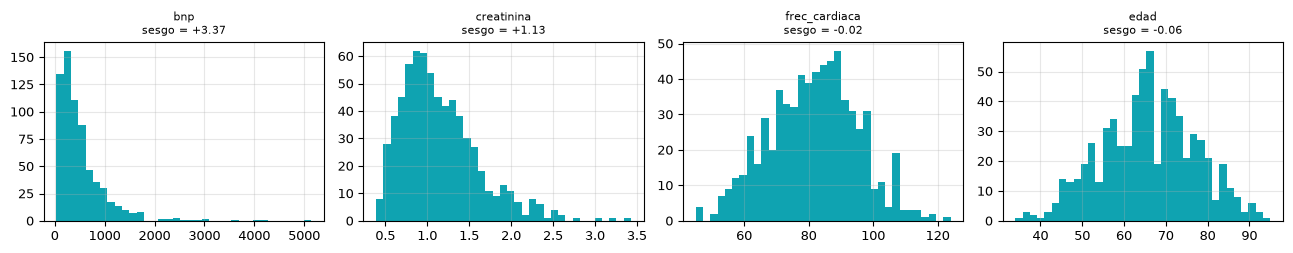

In [ ]:
objetivo = ["bnp", "creatinina", "frec_cardiaca", "edad"]
print(perfil(df_tr, objetivo).to_string(index=False))

fig, ax = plt.subplots(1, 4, figsize=(13, 2.6))
for a, v in zip(ax, objetivo):
    a.hist(df_tr[v], bins=35, color="#0FA3B1")
    a.set_title(f"{v}\nsesgo = {stats.skew(df_tr[v]):+.2f}", fontsize=8)
plt.tight_layout(); plt.show()

# Guarda en "objetivo" las 4 variables numéricas que se van a analizar
# objetivo = ["bnp", "creatinina", "frec_cardiaca", "edad"]


# Muestra el perfil/resumen de las variables seleccionadas sin mostrar el índice
# print(perfil(df_tr, objetivo).to_string(index=False))


# Crea una figura con 4 gráficas en una sola fila y define su tamaño
# fig, ax = plt.subplots(1, 4, figsize=(13, 2.6))


# Recorre al mismo tiempo cada gráfica (a) y cada variable (v)
# for a, v in zip(ax, objetivo):


    # Crea un histograma de la variable con 35 intervalos o barras
    # a.hist(df_tr[v], bins=35, color="#0FA3B1")


    # Coloca como título el nombre de la variable y calcula su sesgo
    # stats.skew() indica qué tan asimétrica es la distribución
    # a.set_title(f"{v}\nsesgo = {stats.skew(df_tr[v]):+.2f}", fontsize=8)


# Ajusta automáticamente el espacio entre las gráficas y después las muestra
# plt.tight_layout(); plt.show()


### PARA RECORDAR EN EL EXAMEN:

# plt.subplots(1, 4) → crea 1 fila con 4 gráficas

# .hist() → crea un HISTOGRAMA

# bins=35 → divide los datos en 35 intervalos

# zip() → permite recorrer dos elementos al mismo tiempo

# stats.skew() → calcula el SESGO de una distribución

# Sesgo ≈ 0 → distribución aproximadamente simétrica
# Sesgo > 0 → cola hacia la DERECHA
# Sesgo < 0 → cola hacia la IZQUIERDA


### IDEA CLAVE:

# Este bloque analiza la distribución de 4 variables numéricas
# mediante su resumen, histogramas y valor de sesgo.

**Tarea.** Decide qué hacer con cada una de las cuatro variables. **No todas requieren lo mismo, y
al menos una no requiere nada.**

In [ ]:
# ============================= TU TURNO =============================
# bnp              -> ?
# creatinina       -> ?
# frec_cardiaca    -> ?
# edad             -> ?
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
df_tr["bnp"] = np.log(df_tr["bnp"])
df_te["bnp"] = np.log(df_te["bnp"])
 
# --- creatinina: sesgo ~ +1, mínimo 0.32, dominio positivo -> LOGARITMO
df_tr["creatinina"] = np.log(df_tr["creatinina"])
df_te["creatinina"] = np.log(df_te["creatinina"])
 
# --- frec_cardiaca: IC 95 % de lambda contiene 1.0 -> NO SE TRANSFORMA
# --- edad: IC 95 % de lambda contiene 1.0 -> NO SE TRANSFORMA
 
for v in objetivo:
    print("%-18s sesgo tras la decisión: %+.2f" % (v, stats.skew(df_tr[v])))


# Aplica logaritmo a BNP en TRAIN para reducir su sesgo positivo
# df_tr["bnp"] = np.log(df_tr["bnp"])

# Aplica la misma transformación a BNP en TEST
# df_te["bnp"] = np.log(df_te["bnp"])


# Aplica logaritmo a creatinina en TRAIN para reducir su sesgo positivo
# df_tr["creatinina"] = np.log(df_tr["creatinina"])

# Aplica la misma transformación a creatinina en TEST
# df_te["creatinina"] = np.log(df_te["creatinina"])


# Frecuencia cardiaca NO se transforma porque no lo necesita
# Edad NO se transforma porque no lo necesita


# Recorre las 4 variables guardadas anteriormente en "objetivo"
# for v in objetivo:

    # Calcula y muestra el sesgo de cada variable DESPUÉS de las transformaciones
    # print("%-18s sesgo tras la decisión: %+.2f" % (v, stats.skew(df_tr[v])))


### PARA RECORDAR EN EL EXAMEN:

# np.log() → aplica una transformación LOGARÍTMICA

# Se puede usar el logaritmo cuando una variable positiva
# tiene un sesgo positivo importante (cola hacia la derecha)

# stats.skew() → calcula el sesgo

# Sesgo cercano a 0 → distribución más simétrica

# IMPORTANTE:
# Si transformo una variable en TRAIN, debo aplicar
# LA MISMA transformación en TEST.


### EN ESTE CASO:

# bnp           → LOGARITMO
# creatinina    → LOGARITMO
# frec_cardiaca → NO se transforma
# edad          → NO se transforma


### IDEA CLAVE:

# No todas las variables necesitan transformación.
# Se transforman BNP y creatinina para reducir su sesgo,
# mientras que frecuencia cardiaca y edad se dejan igual.

bnp                sesgo tras la decisión: +0.09
creatinina         sesgo tras la decisión: +0.04
frec_cardiaca      sesgo tras la decisión: -0.02
edad               sesgo tras la decisión: -0.06


> **Tu justificación.** Completa la tabla:
>
> | Variable | Decisión | Evidencia numérica |
> |---|---|---|
> | `bnp` |Aplicar logaritmo |Después de la transformación, el sesgo quedó en +0.09, cercano a 0. |
> | `creatinina` |Aplicar logaritmo |Después de la transformación, el sesgo quedó en +0.04, cercano a 0. |
> | `frec_cardiaca` | No transformar |Su sesgo es −0.02, muy cercano a 0, por lo que no requiere transformación. |
> | `edad` | No transformar | Su sesgo es −0.06, muy cercano a 0, por lo que no requiere transformación. |


---
## Punto 7 — Escalamiento
*Subtema 4.6*

In [ ]:
num_final = ["edad", "frec_cardiaca", "presion_sistolica", "bnp", "creatinina", "colesterol_total"]
print(df_tr[num_final].describe().T[["mean", "std", "min", "50%", "max"]].round(2).to_string())
print("\nSesgo residual:")
print(df_tr[num_final].apply(lambda s: round(float(stats.skew(s)), 2)).to_string())

# Guarda en num_final las variables numéricas que se van a revisar al final
# num_final = ["edad", "frec_cardiaca", "presion_sistolica", "bnp", "creatinina", "colesterol_total"]


# Muestra un resumen estadístico de las variables: media, desviación estándar,
# mínimo, mediana (50%) y máximo; .T acomoda las variables como filas
# print(df_tr[num_final].describe().T[["mean", "std", "min", "50%", "max"]].round(2).to_string())


# Muestra el título del siguiente análisis
# print("\nSesgo residual:")


# Calcula el sesgo de cada variable numérica después de las transformaciones
# y redondea cada resultado a 2 decimales
# print(df_tr[num_final].apply(lambda s: round(float(stats.skew(s)), 2)).to_string())


### PARA RECORDAR EN EL EXAMEN:

# .describe() → resumen estadístico de las variables

# .T → transpone la tabla (cambia filas por columnas)

# mean → media
# std → desviación estándar
# min → mínimo
# 50% → mediana
# max → máximo

# .apply() → aplica una función a cada columna

# stats.skew() → calcula el sesgo


### IDEA CLAVE:

# Este bloque hace una revisión FINAL de las variables numéricas:
# revisa sus estadísticas principales y el sesgo que quedó
# después de las transformaciones.

                     mean    std    min     50%     max
edad                65.84  11.29  34.00   66.00   95.00
frec_cardiaca       81.54  13.64  45.00   82.00  124.00
presion_sistolica  128.27  18.74  80.00  127.00  185.00
bnp                  5.94   0.82   3.55    5.94    8.55
creatinina           0.06   0.39  -0.94    0.06    1.23
colesterol_total   196.37  39.69  90.00  199.00  322.00

Sesgo residual:
edad                -0.06
frec_cardiaca       -0.02
presion_sistolica    0.21
bnp                  0.09
creatinina           0.04
colesterol_total    -0.13


**Tarea.** Escala las variables numéricas.

> Pregúntale al dato: *¿queda alguna cola pesada que arrastraría la media y la desviación estándar?*

In [ ]:
# ============================= TU TURNO =============================
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
# StandardScaler es adecuado para todas. Ajuste SOLO en entrenamiento.
escalador = StandardScaler().fit(df_tr[num_final])
df_tr[num_final] = escalador.transform(df_tr[num_final])
df_te[num_final] = escalador.transform(df_te[num_final])
 
print(df_tr[num_final].describe().T[["mean", "std", "min", "max"]].round(2).to_string())

# Crea y ajusta el StandardScaler usando SOLO los datos de entrenamiento
# escalador = StandardScaler().fit(df_tr[num_final])


# Escala las variables numéricas de TRAIN con el escalador ya ajustado
# df_tr[num_final] = escalador.transform(df_tr[num_final])


# Escala TEST usando EL MISMO escalador que se ajustó con TRAIN
# df_te[num_final] = escalador.transform(df_te[num_final])


# Muestra media, desviación estándar, mínimo y máximo después del escalado
# print(df_tr[num_final].describe().T[["mean", "std", "min", "max"]].round(2).to_string())


### PARA RECORDAR EN EL EXAMEN:

# StandardScaler() → estandariza las variables numéricas

# .fit() → APRENDE la media y desviación estándar de TRAIN

# .transform() → aplica el escalado aprendido

# Después de StandardScaler esperamos aproximadamente:
# media = 0
# desviación estándar = 1


# ESTRUCTURA GENERAL:
# escalador = StandardScaler().fit(df_tr[columnas])
# df_tr[columnas] = escalador.transform(df_tr[columnas])
# df_te[columnas] = escalador.transform(df_te[columnas])


### IMPORTANTE:

# El escalador se AJUSTA (.fit) SOLO con TRAIN.
# TEST únicamente se TRANSFORMA (.transform).

# Esto evita fuga de información (data leakage).


### IDEA CLAVE:

# StandardScaler pone las variables numéricas en una escala comparable,
# con media cercana a 0 y desviación estándar cercana a 1.

                   mean  std   min   max
edad               -0.0  1.0 -2.82  2.59
frec_cardiaca       0.0  1.0 -2.68  3.12
presion_sistolica  -0.0  1.0 -2.58  3.03
bnp                 0.0  1.0 -2.90  3.17
creatinina         -0.0  1.0 -2.58  3.00
colesterol_total    0.0  1.0 -2.68  3.17



> **Tu justificación:**
>
> _Escribe aquí, citando la evidencia numérica._
>
>Se utilizó StandardScaler porque, después de las transformaciones previas, las variables no presentan colas pesadas importantes. Tras el escalado, todas las variables tienen una media cercana a 0 y una desviación estándar de 1.0, por lo que quedaron en una escala comparable.
>
>Si quieres citar todavía más los números, puedes añadir:
>
>Los valores mínimos quedaron entre −2.58 y −2.90 y los máximos entre 2.59 y 3.17, sin valores extremadamente alejados.
>
>Para examen, la evidencia clave es: media ≈ 0 y std ≈ 1 → StandardScaler funcionó correctamente.


---
## Punto 8 — Entrenamiento y elección de la métrica
*Subtemas 3.5 y 3.1*

In [ ]:
descartar = ["id_paciente", "reingreso_30d"]
X_tr = df_tr.drop(columns=[c for c in descartar if c in df_tr.columns])
X_te = df_te.drop(columns=[c for c in descartar if c in df_te.columns])
y_tr, y_te = df_tr["reingreso_30d"], df_te["reingreso_30d"]

assert X_tr.select_dtypes(exclude=np.number).empty, "Quedan columnas no numéricas"
print("Matriz final -> train:", X_tr.shape, "| test:", X_te.shape)
print("Prevalencia en prueba: %.4f" % y_te.mean())

modelo = LogisticRegression(solver="lbfgs", max_iter=3000, random_state=SEMILLA).fit(X_tr, y_tr)
pred = modelo.predict(X_te); prob = modelo.predict_proba(X_te)[:, 1]

print("\n--- MODELO ------------------------------------------------------")
print("Accuracy : %.4f" % accuracy_score(y_te, pred))
print("Recall   : %.4f" % recall_score(y_te, pred))
print("AUC ROC  : %.4f" % roc_auc_score(y_te, prob))
print("\nMatriz de confusión [fila = real, columna = predicho]:")
print(confusion_matrix(y_te, pred))
print("\n", classification_report(y_te, pred, digits=3))
print("--- Referencia: clasificador trivial 'nadie reingresa' ----------")
print("Accuracy : %.4f" % accuracy_score(y_te, np.zeros_like(y_te)))

# Define las columnas que NO se usarán como variables predictoras
# descartar = ["id_paciente", "reingreso_30d"]


# Crea X_tr eliminando identificador y desenlace del conjunto de entrenamiento
# X_tr = df_tr.drop(columns=[c for c in descartar if c in df_tr.columns])


# Crea X_te eliminando las mismas columnas del conjunto de prueba
# X_te = df_te.drop(columns=[c for c in descartar if c in df_te.columns])


# Separa la variable objetivo: y_tr para entrenamiento y y_te para prueba
# y_tr, y_te = df_tr["reingreso_30d"], df_te["reingreso_30d"]


# Verifica que todas las columnas de X_tr sean numéricas
# Si queda alguna no numérica, marca un error
# assert X_tr.select_dtypes(exclude=np.number).empty, "Quedan columnas no numéricas"


# Muestra las dimensiones finales de train y test
# print("Matriz final -> train:", X_tr.shape, "| test:", X_te.shape)


# Muestra la prevalencia de reingreso en el conjunto de prueba
# print("Prevalencia en prueba: %.4f" % y_te.mean())


# Crea y entrena una regresión logística usando X_tr y y_tr
# modelo = LogisticRegression(solver="lbfgs", max_iter=3000, random_state=SEMILLA).fit(X_tr, y_tr)


# Obtiene las predicciones de clase (0 o 1) sobre TEST
# pred = modelo.predict(X_te)


# Obtiene la probabilidad de pertenecer a la clase 1 (reingreso)
# prob = modelo.predict_proba(X_te)[:, 1]


# Muestra el título de los resultados del modelo
# print("\n--- MODELO ------------------------------------------------------")


# Calcula el accuracy: proporción total de predicciones correctas
# print("Accuracy : %.4f" % accuracy_score(y_te, pred))


# Calcula el recall: proporción de reingresos reales que el modelo detectó
# print("Recall   : %.4f" % recall_score(y_te, pred))


# Calcula el AUC ROC usando las probabilidades predichas
# print("AUC ROC  : %.4f" % roc_auc_score(y_te, prob))


# Muestra el título de la matriz de confusión
# print("\nMatriz de confusión [fila = real, columna = predicho]:")


# Muestra la matriz de confusión
# print(confusion_matrix(y_te, pred))


# Muestra precision, recall, f1-score y support por clase
# print("\n", classification_report(y_te, pred, digits=3))


# Muestra el título del clasificador de referencia
# print("--- Referencia: clasificador trivial 'nadie reingresa' ----------")


# Calcula el accuracy de un modelo que siempre predice 0
# print("Accuracy : %.4f" % accuracy_score(y_te, np.zeros_like(y_te)))


### PARA RECORDAR EN EL EXAMEN:

# X → variables predictoras
# y → variable objetivo

# .drop(columns=...) → elimina columnas

# LogisticRegression().fit(X_tr, y_tr) → entrena el modelo

# .predict(X_te) → predice clases 0/1

# .predict_proba(X_te)[:, 1] → probabilidad de la clase 1


### MÉTRICAS:

# Accuracy → porcentaje total de aciertos

# Recall → de los que SÍ reingresaron,
# cuántos detectó correctamente el modelo

# AUC ROC → capacidad del modelo para separar las dos clases
# más cerca de 1 = mejor


### MATRIZ DE CONFUSIÓN:

# [[VN, FP],
#  [FN, VP]]

# VN = verdadero negativo
# FP = falso positivo
# FN = falso negativo
# VP = verdadero positivo


### IDEA CLAVE:

# Este bloque entrena una regresión logística y evalúa
# qué tan bien predice el reingreso de los pacientes.

Matriz final -> train: (675, 12) | test: (225, 12)
Prevalencia en prueba: 0.5067

--- MODELO ------------------------------------------------------
Accuracy : 0.6489
Recall   : 0.6228
AUC ROC  : 0.7579

Matriz de confusión [fila = real, columna = predicho]:
[[75 36]
 [43 71]]

               precision    recall  f1-score   support

           0      0.636     0.676     0.655       111
           1      0.664     0.623     0.643       114

    accuracy                          0.649       225
   macro avg      0.650     0.649     0.649       225
weighted avg      0.650     0.649     0.649       225

--- Referencia: clasificador trivial 'nadie reingresa' ----------
Accuracy : 0.4933


**Tarea.** Responde en prosa:

1. Compara la accuracy del modelo con la del clasificador trivial. ¿Cuánto aporta el modelo?
2. ¿Qué métrica reportarías aquí, y por qué?


> **Tu justificación:**
>
> _Escribe aquí, citando la evidencia numérica._
>
>1. El modelo obtuvo una accuracy de 0.6489 (64.89%), mientras que el clasificador trivial obtuvo 0.4933 (49.33%). Por lo tanto, el modelo mejora la accuracy en aproximadamente 15.56 puntos porcentuales, mostrando un mejor desempeño que simplemente predecir que ningún paciente reingresa.
>
>2. Reportaría principalmente el AUC ROC, que fue de 0.7579, porque permite evaluar qué tan bien el modelo distingue entre pacientes que reingresan y los que no, sin depender únicamente de una clasificación final. Además, las clases están bastante equilibradas, con 111 pacientes de clase 0 y 114 de clase 1. Como complemento, el recall fue de 0.6228, es decir, el modelo detectó aproximadamente el 62.28% de los pacientes que realmente reingresaron.
>
>Para tu examen, la cuenta de la primera es simplemente:

>64.89% − 49.33% = 15.56 puntos porcentuales de mejora.

---
# Retos finales

<div style="border-left:5px solid #E8912B;background:#f4f7f9;padding:12px 16px;border-radius:5px;font-family:Calibri,Arial,sans-serif;">
<b style="color:#1E2664;">Cambio de formato</b><br>Los dos retos siguientes presentan variables donde <b>la respuesta de hoy no aplica</b>. Este es el tipo de reactivo que aparecer&aacute; en el examen. Resu&eacute;lvelos aunque no alcance el tiempo de clase.
</div>

## Reto A — Una variable con sesgo izquierdo

`fevi_ingreso` (fracción de eyección) es la variable que reservamos al inicio.

sesgo: -0.82
rango: [18, 66]
lambda = +2.19   IC 95% = [+1.95, +2.44]


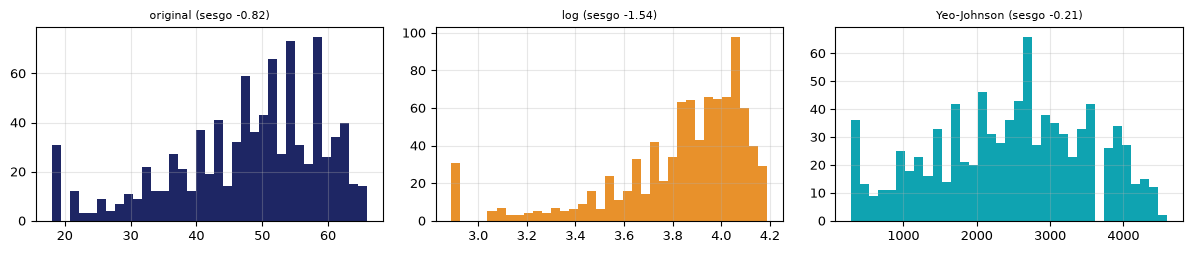

In [ ]:
crudo = cargar("cohorte_ic_repaso.csv")
fevi = crudo["fevi_ingreso"]

print("sesgo:", round(float(stats.skew(fevi)), 2))
print("rango: [%.0f, %.0f]" % (fevi.min(), fevi.max()))
lam, lo, hi = lambda_ic(fevi)
print("lambda = %+.2f   IC 95%% = [%+.2f, %+.2f]" % (lam, lo, hi))

fig, ax = plt.subplots(1, 3, figsize=(12, 2.6))
ax[0].hist(fevi, bins=35, color="#1E2664"); ax[0].set_title(f"original (sesgo {stats.skew(fevi):+.2f})", fontsize=8)
ax[1].hist(np.log(fevi), bins=35, color="#E8912B"); ax[1].set_title(f"log (sesgo {stats.skew(np.log(fevi)):+.2f})", fontsize=8)
yj = stats.yeojohnson(fevi.to_numpy(float))[0]
ax[2].hist(yj, bins=35, color="#0FA3B1"); ax[2].set_title(f"Yeo-Johnson (sesgo {stats.skew(yj):+.2f})", fontsize=8)
plt.tight_layout(); plt.show()

# Carga nuevamente el archivo original para recuperar la variable fevi_ingreso
# crudo = cargar("cohorte_ic_repaso.csv")


# Guarda la columna fevi_ingreso en una variable llamada fevi
# fevi = crudo["fevi_ingreso"]


# Calcula y muestra el sesgo de fevi_ingreso
# print("sesgo:", round(float(stats.skew(fevi)), 2))


# Muestra el valor mínimo y máximo de fevi_ingreso
# print("rango: [%.0f, %.0f]" % (fevi.min(), fevi.max()))


# Calcula lambda y su intervalo de confianza del 95%
# lam, lo, hi = lambda_ic(fevi)


# Muestra lambda y su intervalo de confianza
# print("lambda = %+.2f   IC 95%% = [%+.2f, %+.2f]" % (lam, lo, hi))


# Crea una figura con 3 histogramas en una sola fila
# fig, ax = plt.subplots(1, 3, figsize=(12, 2.6))


# Grafica la distribución ORIGINAL de fevi_ingreso
# ax[0].hist(fevi, bins=35, color="#1E2664")

# Coloca como título el sesgo de la distribución original
# ax[0].set_title(f"original (sesgo {stats.skew(fevi):+.2f})", fontsize=8)


# Grafica fevi_ingreso después de aplicar logaritmo
# ax[1].hist(np.log(fevi), bins=35, color="#E8912B")

# Muestra el sesgo después de aplicar logaritmo
# ax[1].set_title(f"log (sesgo {stats.skew(np.log(fevi)):+.2f})", fontsize=8)


# Aplica la transformación Yeo-Johnson y guarda el resultado en yj
# yj = stats.yeojohnson(fevi.to_numpy(float))[0]


# Grafica la variable transformada con Yeo-Johnson
# ax[2].hist(yj, bins=35, color="#0FA3B1")

# Muestra el sesgo después de Yeo-Johnson
# ax[2].set_title(f"Yeo-Johnson (sesgo {stats.skew(yj):+.2f})", fontsize=8)


# Ajusta los espacios entre gráficas y las muestra
# plt.tight_layout(); plt.show()


### PARA RECORDAR EN EL EXAMEN:

# stats.skew() → calcula el sesgo

# .min() / .max() → mínimo y máximo

# np.log() → transformación logarítmica

# stats.yeojohnson() → transformación Yeo-Johnson

# lambda_ic() → calcula lambda y su IC del 95%


### IDEA CLAVE:

# Este bloque compara tres versiones de fevi_ingreso:
# original, logarítmica y Yeo-Johnson

# La mejor transformación será la que deje el sesgo más cercano a 0
# y sea coherente con el valor de lambda.

**Preguntas.**

1. ¿El logaritmo corrige el sesgo de esta variable? Mira el histograma central y su cifra de sesgo.
2. ¿Por qué λ resulta **mayor** que 1 aquí, cuando en `bnp` resultó ≈ 0?
3. Formula la regla general en una frase.

> **Tu respuesta:**
>1. ¿El logaritmo corrige el sesgo de esta variable?
>No. La variable original tiene un sesgo de −0.82 y al aplicar logaritmo pasa a −1.54, por lo que el sesgo aumenta en lugar de corregirse. En cambio, Yeo-Johnson lo reduce a −0.21, mucho más cercano a 0.
>
>2. ¿Por qué λ resulta mayor que 1 aquí, cuando en BNP resultó ≈ 0?
>Porque fevi_ingreso presenta sesgo negativo (−0.82), es decir, la cola está hacia la izquierda. Por eso necesita una transformación con λ > 1. En BNP el sesgo era hacia la derecha y un λ ≈ 0 corresponde aproximadamente a una transformación logarítmica.
>
>3. Formula la regla general en una frase.
>
>La transformación debe elegirse según la dirección y magnitud del sesgo de cada variable; no se debe aplicar logaritmo automáticamente a todas las variables.
>
>Para tu examen quédate especialmente con esto: sesgo positivo fuerte → el log puede ayudar; sesgo negativo → el log puede empeorarlo, como pasó aquí de −0.82 a −1.54.

## Reto B — Una variable con valores negativos

In [ ]:
# Variable derivada: desviación del BNP respecto al umbral clínico de referencia (400 pg/mL)
delta_bnp = crudo["bnp"] - 400

print("sesgo:", round(float(stats.skew(delta_bnp)), 2))
print("mínimo: %.1f  |  negativos: %d  |  ceros: %d"
      % (delta_bnp.min(), int((delta_bnp < 0).sum()), int((delta_bnp == 0).sum())))

print("\n¿Qué ocurre si aplicamos np.log() ?")
with np.errstate(invalid="ignore", divide="ignore"):
    intento = np.log(delta_bnp)
print("  valores no finitos generados:", int((~np.isfinite(intento)).sum()), "de", len(delta_bnp))

# Crea una nueva variable restando 400 al valor original de BNP
# delta_bnp = crudo["bnp"] - 400


# Calcula y muestra el sesgo de la nueva variable delta_bnp
# print("sesgo:", round(float(stats.skew(delta_bnp)), 2))


# Muestra el mínimo y cuenta cuántos valores negativos y ceros existen
# print("mínimo: %.1f  |  negativos: %d  |  ceros: %d"
#       % (delta_bnp.min(), int((delta_bnp < 0).sum()), int((delta_bnp == 0).sum())))


# Muestra el título de la siguiente prueba
# print("\n¿Qué ocurre si aplicamos np.log() ?")


# Evita que Python muestre advertencias por intentar calcular log de 0 o negativos
# with np.errstate(invalid="ignore", divide="ignore"):


    # Intenta aplicar logaritmo a delta_bnp
    # intento = np.log(delta_bnp)


# Cuenta cuántos valores no finitos (NaN o infinito) produjo el logaritmo
# print("  valores no finitos generados:", int((~np.isfinite(intento)).sum()), "de", len(delta_bnp))


### PARA RECORDAR EN EL EXAMEN:

# np.log() → requiere valores MAYORES que 0

# log(valor negativo) → genera NaN
# log(0) → genera -inf

# np.isfinite() → verifica si un número es finito
# ~ → invierte la condición, por lo que busca los NO finitos

# len() → número total de datos


### IDEA CLAVE:

# No se debe aplicar directamente np.log() a una variable
# que contiene valores negativos o ceros.

sesgo: 3.17
mínimo: -366.7  |  negativos: 480  |  ceros: 0

¿Qué ocurre si aplicamos np.log() ?
  valores no finitos generados: 480 de 900


**Tarea.** El sesgo es positivo y fuerte, así que "hay que transformar". Pero `np.log()` destruye
la mayor parte de la columna.

Aplica la transformación adecuada y comprueba el sesgo resultante.


In [ ]:
# ============================= TU TURNO =============================
# ---- ESCRIBE TU CÓDIGO AQUÍ ----
# El dominio incluye negativos y ceros -> el logaritmo es imposible.
# Yeo-Johnson admite el dominio completo.
pt = PowerTransformer(method="yeo-johnson", standardize=False)
delta_yj = pt.fit_transform(delta_bnp.to_frame())[:, 0]
 
print("lambda estimada: %+.3f" % pt.lambdas_[0])
print("sesgo original : %+.2f" % stats.skew(delta_bnp))
print("sesgo tras YJ  : %+.2f" % stats.skew(delta_yj))
print("valores no finitos:", int((~np.isfinite(delta_yj)).sum()))

# Crea un transformador Yeo-Johnson sin estandarizar los datos
# pt = PowerTransformer(method="yeo-johnson", standardize=False)


# Ajusta Yeo-Johnson a delta_bnp y transforma la variable
# [:, 0] convierte el resultado de 2D a una sola columna
# delta_yj = pt.fit_transform(delta_bnp.to_frame())[:, 0]


# Muestra el valor de lambda estimado por Yeo-Johnson
# print("lambda estimada: %+.3f" % pt.lambdas_[0])


# Muestra el sesgo original de delta_bnp
# print("sesgo original : %+.2f" % stats.skew(delta_bnp))


# Muestra el sesgo después de aplicar Yeo-Johnson
# print("sesgo tras YJ  : %+.2f" % stats.skew(delta_yj))


# Cuenta cuántos valores no finitos quedaron después de la transformación
# print("valores no finitos:", int((~np.isfinite(delta_yj)).sum()))


### PARA RECORDAR EN EL EXAMEN:

# PowerTransformer(method="yeo-johnson")
# → transforma variables con sesgo y admite valores negativos y cero

# fit_transform()
# → aprende la transformación y la aplica

# pt.lambdas_[0]
# → muestra la lambda estimada

# stats.skew()
# → calcula el sesgo

# ~np.isfinite()
# → detecta NaN o infinito


### IDEA CLAVE:

# Como delta_bnp tiene negativos y ceros, np.log() no sirve.

# Yeo-Johnson sí puede usarse con negativos, ceros y positivos.

# Si el sesgo después de Yeo-Johnson queda más cerca de 0,
# la transformación mejoró la distribución.

lambda estimada: +0.856
sesgo original : +3.17
sesgo tras YJ  : +0.42
valores no finitos: 0


> **Tu conclusión en una frase:** Se utilizó Yeo-Johnson porque la variable contiene valores negativos y ceros, por lo que no es posible aplicar logaritmo, logrando reducir el sesgo sin generar valores no finitos.


---
# Mapa de decisiones — guía de estudio

**Esta tabla es lo que debes estudiar.** No las celdas de código: **las preguntas de la columna central**.

| # | Punto de decisión | La pregunta que le haces al dato | Hoy la respuesta fue |
|---|---|---|---|
| 1 | Integridad y segregación | ¿La fila y la unidad de observación son la misma cosa? | Sí (900 filas = 900 pacientes) → partición estándar |
| 2 | Variables admisibles | ¿Alguna variable se registra **después** del desenlace? | No → no se elimina nada |
| 3 | Atípicos | ¿Este valor es **raro** o es **imposible**? | Colesterol 0 = imposible (corregir) · BNP alto = real (conservar) |
| 4 | Faltantes | ¿El **hecho de que falte** me dice algo? | No (MCAR) → imputación simple, sin indicador |
| 5 | Codificación | ¿Los niveles tienen un **orden monótono** verificable? | No → one-hot para las tres |
| 6 | Corrección del sesgo | ¿Qué **dirección**? ¿El **dominio** admite log? ¿El **IC de λ** excluye a 1? | Log en `bnp` y `creatinina` · sin transformar en las otras dos |
| 7 | Escalamiento | ¿Queda alguna **cola pesada** que arrastre la media? | No → `StandardScaler` |
| 8 | Métrica | ¿Cuánto supero al **clasificador trivial**? | Bastante (≈ 50 % de prevalencia) → accuracy interpretable |

### En el examen

Los ocho puntos serán **los mismos** y en **el mismo orden**. El conjunto de datos será distinto, y por eso
**varias respuestas de la última columna serán otras**. El examen es enteramente práctico y dura 90 minutos.

Se te calificará en tres componentes por punto: **ejecución** (el código corre), **decisión** (elegiste lo que
el dato exige) y **justificación** (citaste la evidencia numérica). Una decisión correcta sin evidencia que la
respalde vale la mitad, y una decisión equivocada que tú mismo detectes y corrijas conserva puntaje parcial.

### Lista de verificación antes del examen

- [ ] Sé comprobar si hay registros duplicados por sujeto, y qué hacer si los hay.
- [ ] Sé distinguir un error de captura de un valor extremo clínicamente válido.
- [ ] Sé comparar el perfil de los casos con y sin dato faltante para decidir si la ausencia es informativa.
- [ ] Sé verificar si una variable categórica tiene orden monótono antes de codificarla.
- [ ] Sé leer la **dirección** del sesgo, no solo su magnitud.
- [ ] Sé revisar el mínimo y el conteo de negativos antes de intentar un logaritmo.
- [ ] Sé interpretar el IC 95 % de λ para decidir **no** transformar.
- [ ] Sé calcular el desempeño del clasificador trivial y comparar contra él.


Siii, claro. Te lo dejo como **apuntes normales, sin ningún `#`**, para que sea más fácil leerlo y estudiar.

## CHULETA / LISTA DE VERIFICACIÓN PARA EL EXAMEN

### 1. COMPROBAR REGISTROS DUPLICADOS POR PACIENTE

Número total de filas:

```python
len(df)
```

Número de pacientes únicos:

```python
df["id_paciente"].nunique()
```

Número de registros repetidos:

```python
len(df) - df["id_paciente"].nunique()
```

**Recuerda:**
Si filas = pacientes únicos → 1 fila = 1 paciente.
Si no son iguales → hay pacientes repetidos y debo revisarlos.

---

### 2. DISTINGUIR VALOR ATÍPICO DE VALOR INVÁLIDO

Calcular límites IQR:

```python
q1, q3 = s.quantile([.25, .75])
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
```

Contar valores fuera de los límites:

```python
((s < lo) | (s > hi)).sum()
```

Ver mínimo y máximo:

```python
s.min()
s.max()
```

Reemplazar un valor inválido por NaN:

```python
df["columna"] = df["columna"].replace(0, np.nan)
```

**Recuerda:** Atípico ≠ incorrecto. Primero pregunto: **¿es raro o es imposible?**

---

### 3. ANALIZAR DATOS FALTANTES

Porcentaje de faltantes:

```python
df.isna().mean() * 100
```

Crear indicador de dato faltante:

```python
falta = df["columna"].isna()
```

Comparar pacientes con y sin el dato:

```python
df.groupby(falta)[["edad", "bnp", "creatinina"]].mean()
```

**Recuerda:**
False → dato presente
True → dato ausente

Si ambos grupos son parecidos → una imputación simple puede ser suficiente.

---

### 4. IMPUTAR DATOS FALTANTES

Calcular mediana solo con TRAIN:

```python
mediana = df_tr["columna"].median()
```

Rellenar faltantes:

```python
df_tr["columna"] = df_tr["columna"].fillna(mediana)
df_te["columna"] = df_te["columna"].fillna(mediana)
```

Comprobar que no queden faltantes:

```python
df_tr["columna"].isna().sum()
```

**Recuerda:** la mediana se obtiene de **TRAIN** y esa misma se aplica a **TEST**.

---

### 5. REVISAR VARIABLES CATEGÓRICAS

Cuántas categorías existen:

```python
df["columna"].nunique()
```

Cuáles categorías existen:

```python
df["columna"].unique()
```

Comparar desenlace entre categorías:

```python
df.groupby("columna")["reingreso_30d"].agg(["size", "mean"])
```

**Recuerda:** antes de asumir que una variable tiene orden, reviso si realmente existe una progresión **monótona**.

---

### 6. CODIFICAR VARIABLES CATEGÓRICAS

Convertir categorías en columnas 0/1:

```python
df_tr = pd.get_dummies(
    df_tr,
    columns=["sexo", "tipo_dolor"],
    drop_first=True,
    dtype=int
)
```

Hacer que TEST tenga las mismas columnas que TRAIN:

```python
df_te = df_te.reindex(columns=df_tr.columns, fill_value=0)
```

**Recuerda:**
`get_dummies()` → categorías a 0/1
`drop_first=True` → deja una categoría como referencia.

---

### 7. ANALIZAR EL SESGO

```python
stats.skew(df["columna"])
```

**Recuerda:**

* Sesgo ≈ 0 → simétrica
* Sesgo > 0 → cola hacia la derecha
* Sesgo < 0 → cola hacia la izquierda

Importa tanto la **magnitud como el signo**.

---

### 8. DECIDIR SI PUEDO USAR LOGARITMO

Revisar mínimo:

```python
df["columna"].min()
```

Contar negativos:

```python
(df["columna"] < 0).sum()
```

Contar ceros:

```python
(df["columna"] == 0).sum()
```

Aplicar logaritmo:

```python
df["columna"] = np.log(df["columna"])
```

**Recuerda:** `np.log()` necesita valores **mayores que 0**.

Negativos → `NaN`
Cero → `-inf`

---

### 9. USAR YEO-JOHNSON

Crear transformador:

```python
pt = PowerTransformer(method="yeo-johnson", standardize=False)
```

Ajustar y transformar:

```python
nueva = pt.fit_transform(df[["columna"]])[:, 0]
```

Ver lambda:

```python
pt.lambdas_[0]
```

Ver nuevo sesgo:

```python
stats.skew(nueva)
```

**Recuerda:** Yeo-Johnson admite **negativos, ceros y positivos**.

---

### 10. INTERPRETAR LAMBDA E IC 95%

```python
lam, lo, hi = lambda_ic(df["columna"])
```

**Recuerda:**

λ ≈ 1 → prácticamente no transformar.
λ ≈ 0 → transformación parecida al logaritmo.

Si el **IC 95% de λ contiene 1**, no hay evidencia fuerte de que sea necesario transformar.

---

### 11. ESCALAR VARIABLES NUMÉRICAS

Ajustar solo con TRAIN:

```python
escalador = StandardScaler().fit(df_tr[columnas])
```

Transformar TRAIN:

```python
df_tr[columnas] = escalador.transform(df_tr[columnas])
```

Transformar TEST con el mismo escalador:

```python
df_te[columnas] = escalador.transform(df_te[columnas])
```

**Recuerda:**

`fit()` → aprende de TRAIN.
`transform()` → aplica lo aprendido.

Después de StandardScaler:

**media ≈ 0**
**std ≈ 1**

---

### 12. SEPARAR X E y

Variables predictoras:

```python
X_tr = df_tr.drop(columns=["id_paciente", "reingreso_30d"])
X_te = df_te.drop(columns=["id_paciente", "reingreso_30d"])
```

Variable objetivo:

```python
y_tr = df_tr["reingreso_30d"]
y_te = df_te["reingreso_30d"]
```

**Recuerda:**
X → variables que usa el modelo.
y → lo que quiero predecir.

---

### 13. ENTRENAR EL MODELO

```python
modelo = LogisticRegression().fit(X_tr, y_tr)
```

Predecir clases:

```python
pred = modelo.predict(X_te)
```

Predecir probabilidades:

```python
prob = modelo.predict_proba(X_te)[:, 1]
```

**Recuerda:**
`predict()` → clase 0/1
`predict_proba()` → probabilidad

---

### 14. EVALUAR EL MODELO

Accuracy:

```python
accuracy_score(y_te, pred)
```

Recall:

```python
recall_score(y_te, pred)
```

AUC ROC:

```python
roc_auc_score(y_te, prob)
```

Matriz de confusión:

```python
confusion_matrix(y_te, pred)
```

Reporte completo:

```python
classification_report(y_te, pred)
```

**Recuerda:**

**Accuracy** → porcentaje total de aciertos.
**Recall** → de los que realmente eran 1, cuántos detectó.
**AUC ROC** → capacidad para distinguir las dos clases; más cerca de 1 = mejor.

Matriz de confusión:

```text
[[VN, FP],
 [FN, VP]]
```

---

### 15. CLASIFICADOR TRIVIAL

Modelo que predice que todos son 0:

```python
accuracy_score(y_te, np.zeros_like(y_te))
```

Comparar:

```text
aporte = accuracy modelo - accuracy trivial
```

En tu práctica:

```text
0.6489 - 0.4933 = 0.1556
```

→ **15.56 puntos porcentuales de mejora.**

---

## LO QUE MÁS ME APRENDERÍA

```python
df["id"].nunique()                → valores únicos

df.isna().sum()                   → cantidad de faltantes

df.isna().mean() * 100            → porcentaje de faltantes

df["columna"].fillna(mediana)     → imputar faltantes

df["columna"].nunique()           → cuántas categorías

df["columna"].unique()            → cuáles categorías

df.groupby("grupo").mean()        → comparar grupos

stats.skew(df["columna"])         → calcular sesgo

np.log(df["columna"])             → logaritmo

StandardScaler().fit()            → aprender escalado

.transform()                      → aplicar escalado

modelo.fit(X_tr, y_tr)            → entrenar

modelo.predict(X_te)              → predecir

accuracy_score()                  → accuracy

recall_score()                    → recall

roc_auc_score()                   → AUC ROC

confusion_matrix()                → matriz de confusión
```

Y el **orden mental** para que no te pierdas en el examen:

**Revisar datos → detectar errores/atípicos → tratar faltantes → codificar categóricas → revisar sesgo → transformar → escalar → separar X/y → entrenar → evaluar.**
